---
Phase 5-Diffusion-1: 擴散模型 — 從噪聲到圖像
---

Diffusion Models 是目前最強的圖像生成模型。
Stable Diffusion, DALL-E, Midjourney 都是基於它。

核心想法超簡單：
  1. 前向過程：逐步在圖片上加噪聲，直到變成純噪聲
  2. 反向過程：學會「去噪」，從純噪聲還原出圖片

本檔涵蓋：
  1. 擴散模型的直覺
  2. 前向過程（加噪聲）
  3. 反向過程（去噪）
  4. 簡單的擴散模型實作
  5. Stable Diffusion 架構概覽

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

# ============================================================================
# 1. 擴散模型的直覺
# ============================================================================

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
print("=" * 60)
print("1. 擴散模型 — 加噪然後去噪")
print("=" * 60)

print("""
前向過程 (Forward / Diffusion):
  x_0 → x_1 → x_2 → ... → x_T
  清晰     加一點噪聲      純噪聲

  每一步加一點高斯噪聲：
  x_t = √(1-β_t) × x_{t-1} + √β_t × ε
  ε ~ N(0, I)

反向過程 (Reverse / Denoising):
  x_T → x_{T-1} → ... → x_1 → x_0
  純噪聲    去一點噪聲      清晰

  學一個神經網路來預測加的噪聲：
  ε_θ(x_t, t) ≈ ε

  知道噪聲之後就能把它去掉！

訓練：
  1. 從資料集取一張圖 x_0
  2. 隨機取一個時間步 t
  3. 加噪聲得到 x_t
  4. 讓網路預測加的噪聲 ε_θ(x_t, t)
  5. Loss = ||ε - ε_θ(x_t, t)||²
""")

1. 擴散模型 — 加噪然後去噪

前向過程 (Forward / Diffusion):
  x_0 → x_1 → x_2 → ... → x_T
  清晰     加一點噪聲      純噪聲

  每一步加一點高斯噪聲：
  x_t = √(1-β_t) × x_{t-1} + √β_t × ε
  ε ~ N(0, I)

反向過程 (Reverse / Denoising):
  x_T → x_{T-1} → ... → x_1 → x_0
  純噪聲    去一點噪聲      清晰

  學一個神經網路來預測加的噪聲：
  ε_θ(x_t, t) ≈ ε

  知道噪聲之後就能把它去掉！

訓練：
  1. 從資料集取一張圖 x_0
  2. 隨機取一個時間步 t
  3. 加噪聲得到 x_t
  4. 讓網路預測加的噪聲 ε_θ(x_t, t)
  5. Loss = ||ε - ε_θ(x_t, t)||²



## 2. 前向過程 — 加噪聲

2. 前向過程 — 逐步加噪

噪聲排程 (Noise Schedule):
  β_1, β_2, ..., β_T   (β 從小到大)
  通常 β ∈ [0.0001, 0.02], T = 1000

重要性質 — 可以直接跳到任意時間步 t：
  α_t = 1 - β_t
  ᾱ_t = α_1 × α_2 × ... × α_t  (累積乘積)

  x_t = √ᾱ_t × x_0 + √(1-ᾱ_t) × ε

  → 不用一步步加，直接算出 t 步後的結果！

加噪過程視覺化:


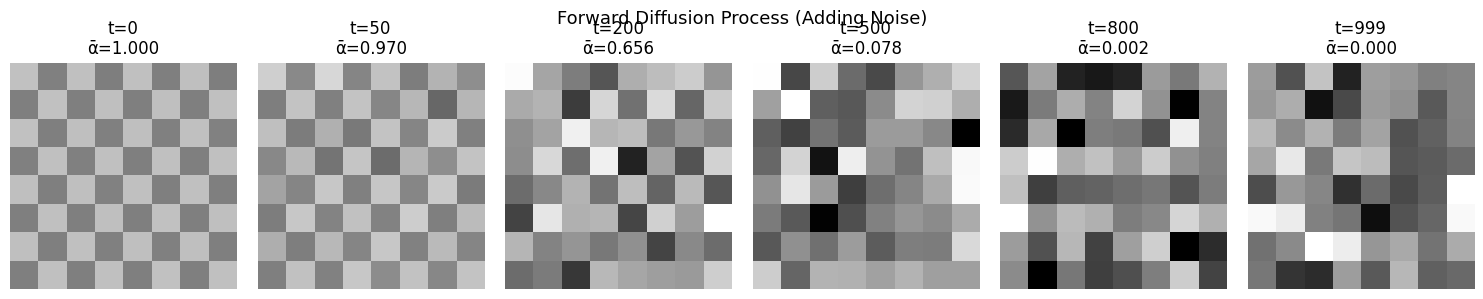

→ 圖表儲存至 diffusion/plots/01_forward_process.png


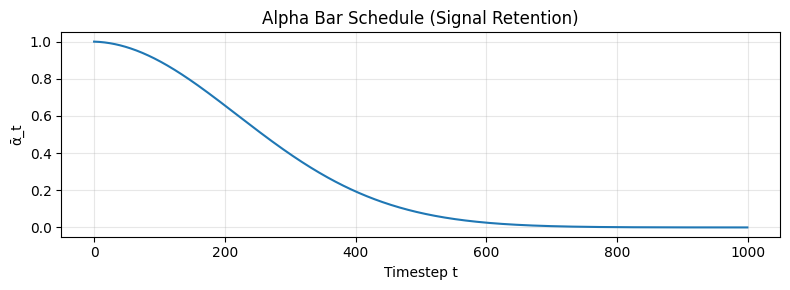

→ 圖表儲存至 diffusion/plots/01_alpha_schedule.png


In [3]:
print("=" * 60)
print("2. 前向過程 — 逐步加噪")
print("=" * 60)

print("""
噪聲排程 (Noise Schedule):
  β_1, β_2, ..., β_T   (β 從小到大)
  通常 β ∈ [0.0001, 0.02], T = 1000

重要性質 — 可以直接跳到任意時間步 t：
  α_t = 1 - β_t
  ᾱ_t = α_1 × α_2 × ... × α_t  (累積乘積)

  x_t = √ᾱ_t × x_0 + √(1-ᾱ_t) × ε

  → 不用一步步加，直接算出 t 步後的結果！
""")


class DiffusionSchedule:
    """線性噪聲排程"""
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def to(self, device):
        """移到指定裝置"""
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alpha_bars = self.alpha_bars.to(device)
        return self

    def add_noise(self, x_0, t, noise=None):
        """前向過程：x_0 → x_t"""
        if noise is None:
            noise = torch.randn_like(x_0)

        alpha_bar = self.alpha_bars[t]
        # 處理維度 (batch)
        while alpha_bar.dim() < x_0.dim():
            alpha_bar = alpha_bar.unsqueeze(-1)

        x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * noise
        return x_t, noise


schedule = DiffusionSchedule(T=1000)

# 展示加噪過程
print("加噪過程視覺化:")

# 建立一個簡單的「圖片」(8×8 的棋盤格)
x_0 = torch.zeros(1, 1, 8, 8)
x_0[0, 0, ::2, ::2] = 1.0
x_0[0, 0, 1::2, 1::2] = 1.0

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
timesteps = [0, 50, 200, 500, 800, 999]

torch.manual_seed(42)
for i, t in enumerate(timesteps):
    t_tensor = torch.tensor([t])
    x_t, _ = schedule.add_noise(x_0, t_tensor)
    axes[i].imshow(x_t[0, 0].numpy(), cmap='gray', vmin=-2, vmax=2)
    alpha_bar = schedule.alpha_bars[t].item()
    axes[i].set_title(f't={t}\nᾱ={alpha_bar:.3f}')
    axes[i].axis('off')

plt.suptitle('Forward Diffusion Process (Adding Noise)', fontsize=13)
plt.tight_layout()
plt.savefig('phase-5-modern/diffusion/plots/01_forward_process.png', dpi=100)
plt.show()
print("→ 圖表儲存至 diffusion/plots/01_forward_process.png")

# α_bar 的變化
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(schedule.alpha_bars.numpy())
ax.set_xlabel('Timestep t')
ax.set_ylabel('ᾱ_t')
ax.set_title('Alpha Bar Schedule (Signal Retention)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-5-modern/diffusion/plots/01_alpha_schedule.png', dpi=100)
plt.show()
print("→ 圖表儲存至 diffusion/plots/01_alpha_schedule.png")

## 3. 去噪網路

In [4]:
print("\n" + "=" * 60)
print("3. 去噪網路 — 預測噪聲")
print("=" * 60)

print("""
去噪網路 ε_θ(x_t, t) 的架構：
  輸入: 加噪的圖片 x_t 和 時間步 t
  輸出: 預測的噪聲 ε

  通常用 U-Net 架構：
  ┌────────────────────────────────┐
  │  x_t ──→ Encoder ──→ Bottleneck ──→ Decoder ──→ ε_predicted
  │           ↓ skip connections ↑
  │  t ──→ Time Embedding (sinusoidal) ──→ 注入每一層
  └────────────────────────────────┘

  時間步嵌入: 用正弦函數把 t 編碼成向量
  （和 Transformer 的位置編碼很像！）
""")


class TimeEmbedding(nn.Module):
    """時間步嵌入（正弦編碼）"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float) * -emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


class SimpleDenoiser(nn.Module):
    """簡單的去噪網路（用於小圖）"""
    def __init__(self, img_channels=1, img_size=8, time_dim=32, hidden=64):
        super().__init__()
        self.time_emb = TimeEmbedding(time_dim)
        self.time_proj = nn.Linear(time_dim, hidden)

        flat_dim = img_channels * img_size * img_size
        self.net = nn.Sequential(
            nn.Linear(flat_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, flat_dim),
        )
        self.img_shape = (img_channels, img_size, img_size)

    def forward(self, x, t):
        B = x.shape[0]
        x_flat = x.view(B, -1)

        t_emb = F.relu(self.time_proj(self.time_emb(t)))

        # 加入時間資訊
        h = x_flat + t_emb[:, :x_flat.shape[1]].expand_as(x_flat) * 0.1
        h = self.net(h)
        return h.view(B, *self.img_shape)


# 測試
model = SimpleDenoiser()
x = torch.randn(4, 1, 8, 8)
t = torch.randint(0, 1000, (4,))
noise_pred = model(x, t)
print(f"去噪網路: {x.shape} → {noise_pred.shape}")
print(f"參數量: {sum(p.numel() for p in model.parameters()):,}")


3. 去噪網路 — 預測噪聲

去噪網路 ε_θ(x_t, t) 的架構：
  輸入: 加噪的圖片 x_t 和 時間步 t
  輸出: 預測的噪聲 ε

  通常用 U-Net 架構：
  ┌────────────────────────────────┐
  │  x_t ──→ Encoder ──→ Bottleneck ──→ Decoder ──→ ε_predicted
  │           ↓ skip connections ↑
  │  t ──→ Time Embedding (sinusoidal) ──→ 注入每一層
  └────────────────────────────────┘

  時間步嵌入: 用正弦函數把 t 編碼成向量
  （和 Transformer 的位置編碼很像！）



去噪網路: torch.Size([4, 1, 8, 8]) → torch.Size([4, 1, 8, 8])
參數量: 18,752


## 4. 訓練和取樣


4. 訓練去噪模型
訓練資料: torch.Size([300, 1, 8, 8])


訓練中...


  Epoch   0: Loss = 1.0320
  Epoch  50: Loss = 0.9577


  Epoch 100: Loss = 0.8172
  Epoch 150: Loss = 0.7985



生成圖片...


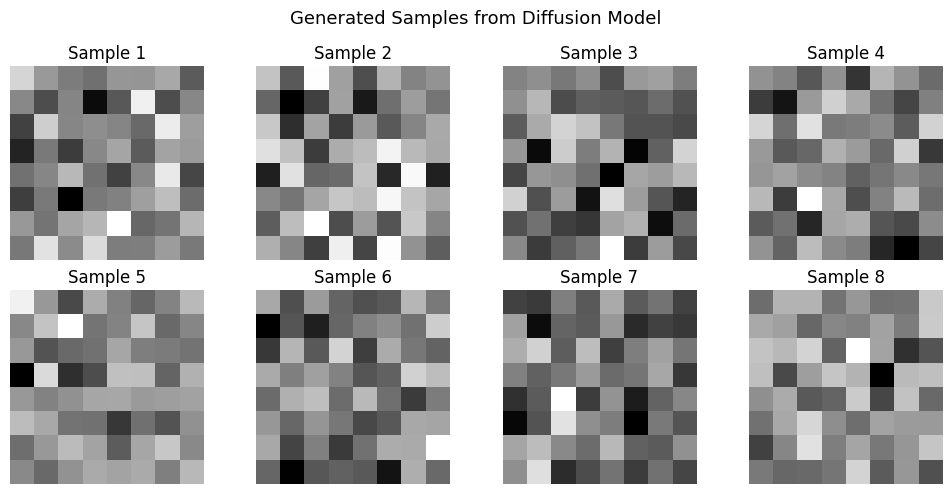

→ 圖表儲存至 diffusion/plots/01_generated_samples.png


In [5]:
print("\n" + "=" * 60)
print("4. 訓練去噪模型")
print("=" * 60)

# 建立簡單的訓練資料（棋盤格 + 對角線 + 十字）
def make_patterns(n=200):
    patterns = []
    for _ in range(n):
        p = np.random.choice(3)
        img = np.zeros((8, 8), dtype=np.float32)
        if p == 0:  # 棋盤格
            img[::2, ::2] = 1
            img[1::2, 1::2] = 1
        elif p == 1:  # 對角線
            for i in range(8):
                img[i, i] = 1
                img[i, 7-i] = 1
        else:  # 十字
            img[3:5, :] = 1
            img[:, 3:5] = 1
        patterns.append(img)
    return torch.tensor(np.array(patterns)).unsqueeze(1)  # (N, 1, 8, 8)


data = make_patterns(300)
print(f"訓練資料: {data.shape}")

# 訓練
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleDenoiser().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
schedule = DiffusionSchedule(T=200)  # 用少一點的步數
schedule.to(device)

data = data.to(device)
losses = []

print("訓練中...")
for epoch in range(200):
    # 隨機選一批資料
    idx = torch.randint(0, len(data), (32,))
    x_0 = data[idx]

    # 隨機選時間步
    t = torch.randint(0, schedule.T, (32,), device=device)

    # 加噪
    noise = torch.randn_like(x_0)
    x_t, _ = schedule.add_noise(x_0, t, noise)

    # 預測噪聲
    noise_pred = model(x_t, t)
    loss = F.mse_loss(noise_pred, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d}: Loss = {loss.item():.4f}")

# 取樣（從噪聲生成圖片）
@torch.no_grad()
def sample(model, schedule, n_samples=4, device='cpu'):
    """DDPM 取樣"""
    model.eval()
    x = torch.randn(n_samples, 1, 8, 8, device=device)

    for t in reversed(range(schedule.T)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

        # 預測噪聲
        noise_pred = model(x, t_batch)

        alpha = schedule.alphas[t]
        alpha_bar = schedule.alpha_bars[t]
        beta = schedule.betas[t]

        # 去噪一步
        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0

        x = (1 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1 - alpha_bar)) * noise_pred
        ) + torch.sqrt(beta) * noise

    return x


print("\n生成圖片...")
samples = sample(model, schedule, n_samples=8, device=device)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(8):
    ax = axes[i // 4, i % 4]
    ax.imshow(samples[i, 0].cpu().numpy(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Sample {i+1}')
plt.suptitle('Generated Samples from Diffusion Model', fontsize=13)
plt.tight_layout()
plt.savefig('phase-5-modern/diffusion/plots/01_generated_samples.png', dpi=100)
plt.show()
print("→ 圖表儲存至 diffusion/plots/01_generated_samples.png")

## 5. Stable Diffusion 架構

In [6]:
print("\n" + "=" * 60)
print("5. Stable Diffusion — 實際的擴散模型")
print("=" * 60)

print("""
Stable Diffusion 的架構：

  ┌──────────────────────────────────────────┐
  │ 文字 "a cat on the moon"                  │
  │   ↓                                       │
  │ Text Encoder (CLIP)                       │
  │   ↓ text embedding                        │
  │ ┌────────────────────────────┐            │
  │ │ Latent Space (壓縮版的圖片) │            │
  │ │   ↓                        │            │
  │ │ U-Net (去噪) ← text emb   │  反覆去噪   │
  │ │   ↓                        │            │
  │ │ x_{t-1}                    │            │
  │ └────────────────────────────┘            │
  │   ↓                                       │
  │ VAE Decoder (放大回圖片)                   │
  │   ↓                                       │
  │ 生成的圖片 512×512                         │
  └──────────────────────────────────────────┘

  關鍵組件：
  1. VAE: 把圖片壓縮到 latent space（64×64 而不是 512×512）
     → 大幅減少計算量！
  2. U-Net: 去噪網路，加入 cross-attention 看文字
  3. CLIP Text Encoder: 把文字轉成 embedding
  4. Scheduler: 控制加噪/去噪的步驟

  其他重要概念：
  - Classifier-Free Guidance: 同時用有/無條件去噪，增強文字控制
  - ControlNet: 加入額外的控制（邊緣、姿勢、深度）
  - LoRA: 用少量參數微調風格
  - SDXL, SD3: 更大更好的版本

  最新趨勢：
  - Flow Matching (SD3, Flux): 比 DDPM 更簡單的訓練方式
  - DiT (Diffusion Transformer): 用 Transformer 取代 U-Net
""")


5. Stable Diffusion — 實際的擴散模型

Stable Diffusion 的架構：

  ┌──────────────────────────────────────────┐
  │ 文字 "a cat on the moon"                  │
  │   ↓                                       │
  │ Text Encoder (CLIP)                       │
  │   ↓ text embedding                        │
  │ ┌────────────────────────────┐            │
  │ │ Latent Space (壓縮版的圖片) │            │
  │ │   ↓                        │            │
  │ │ U-Net (去噪) ← text emb   │  反覆去噪   │
  │ │   ↓                        │            │
  │ │ x_{t-1}                    │            │
  │ └────────────────────────────┘            │
  │   ↓                                       │
  │ VAE Decoder (放大回圖片)                   │
  │   ↓                                       │
  │ 生成的圖片 512×512                         │
  └──────────────────────────────────────────┘

  關鍵組件：
  1. VAE: 把圖片壓縮到 latent space（64×64 而不是 512×512）
     → 大幅減少計算量！
  2. U-Net: 去噪網路，加入 cross-attention 看文字
  3. CLIP Text Encoder: 把文字轉成 embeddin

## 小結

In [7]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
擴散模型核心：

  前向: x_t = √ᾱ_t × x_0 + √(1-ᾱ_t) × ε
  訓練: minimize ||ε - ε_θ(x_t, t)||²
  取樣: x_{t-1} = denoise(x_t, ε_θ(x_t, t))

  演進：
    DDPM (2020)   → 基礎擴散模型
    DDIM (2020)   → 加速取樣（不用 1000 步）
    LDM  (2022)   → 在 latent space 做擴散 = Stable Diffusion
    SD3  (2024)   → Flow Matching + DiT

  實務工具：
    - diffusers (Hugging Face): 各種擴散模型的套件
    - ComfyUI: 視覺化的生成工作流
    - A1111 WebUI: 最流行的生成 UI

Phase 5 Diffusion 完成！
""")


小結

擴散模型核心：

  前向: x_t = √ᾱ_t × x_0 + √(1-ᾱ_t) × ε
  訓練: minimize ||ε - ε_θ(x_t, t)||²
  取樣: x_{t-1} = denoise(x_t, ε_θ(x_t, t))

  演進：
    DDPM (2020)   → 基礎擴散模型
    DDIM (2020)   → 加速取樣（不用 1000 步）
    LDM  (2022)   → 在 latent space 做擴散 = Stable Diffusion
    SD3  (2024)   → Flow Matching + DiT

  實務工具：
    - diffusers (Hugging Face): 各種擴散模型的套件
    - ComfyUI: 視覺化的生成工作流
    - A1111 WebUI: 最流行的生成 UI

Phase 5 Diffusion 完成！

